# 7DS: Origin — UA Opportunity: Retention as a Predictor of I2P and ARPPU

| Field | Value |
|-------|-------|
| **Author** | Haewon Yum |
| **Date** | 2026-04-28 |
| **Ticket** | [ODSB-17637](https://mlc.atlassian.net/browse/ODSB-17637) |
| **Bundle** | `com.netmarble.nanaori` (Android) |
| **Launch date** | 2026-04-06 |
| **Objective** | Validate whether users with longer early retention deliver higher Install-to-Purchase (I2P) rates and higher ARPPU — and quantify the LTV premium of a retained user vs. a churned one. |
| **Scope** | All geos, Android only, D0–D14 post-install window (D14 as primary LTV proxy due to 22-day title age). D21 supplemental for Apr 6–10 cohorts only. |
| **Tables** | `focal-elf-631.prod_stream_view.pb` (unsampled) |
| **Related** | `260428_7DS_origin_RE_opportunity_analysis.ipynb`, `260428_7DS_origin_UA_retention_ltv_plan.md` |

---

## Hypothesis

Early retention is a positive predictor of lifetime monetization:

| # | Sub-hypothesis | Expected signal |
|---|---------------|-----------------|
| H1 | Retained users convert to payers at higher rates | I2P: D14-retained > D7-retained > D1-retained > D0-only |
| H2 | Retained users spend more per payer | ARPPU monotonically higher in longer-retained segments |
| H3 | Revenue gap widens over time | ARPU gap between retained/churned cohorts grows from D7 → D14 |

> **Causal note:** Retention and monetization are both driven by underlying user quality. Longer retention does not *cause* higher ARPPU — a highly engaged user will do both naturally. The actionable implication: early retention is a **leading indicator** of LTV, so UA should be evaluated against D7 retention quality, not just CPI.

## Environment Setup

In [15]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='moloco-ods')

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'✅ {label}: {len(df)} rows')
    return df

CHART_DIR = os.getcwd()
print(f'Chart dir: {CHART_DIR}')

Chart dir: /Users/haewon.yum/Documents/Queries/premium_support/netmarble/Launch_7DS_Origin_2603/notebooks


## Parameters

In [16]:
PB_TABLE   = 'focal-elf-631.prod_stream_view.pb'
BUNDLE_ID  = 'com.netmarble.nanaori'
LAUNCH_DATE = '2026-04-06'
TODAY       = '2026-04-29'

# D14 is the primary LTV proxy — all install cohorts have >=14 days of observation
# as of today (Apr 29). D21 is only available for installs Apr 6-8.
LTV_WINDOW_DAYS = 14

print(f'Bundle:      {BUNDLE_ID}')
print(f'Launch date: {LAUNCH_DATE}')
print(f'Today:       {TODAY}')
print(f'LTV window:  D{LTV_WINDOW_DAYS}')

Bundle:      com.netmarble.nanaori
Launch date: 2026-04-06
Today:       2026-04-29
LTV window:  D14


---

## Section 0 — Retention Curve

**Objective:** Plot D1, D3, D7, D14, D21 retention rates for the full install cohort.

**Why:** Establishes how quickly users churn and whether there is a natural stickiness threshold. Baseline to benchmark against genre norms (Korean mobile RPG D7 benchmark: ~20–30%).

**Logic:** For each user who installed on day D, check if they had ≥1 non-install event on exactly day D+N (or within the D0–DN window for rolling retention).

**Caveat:** D21 observable only for cohorts installed Apr 6–8 (≤3 days). Flag n < 500 as directional.

In [17]:
SESSION_EVENTS = "('af_app_opened', 'login')"
VALIDATION_END = '2026-04-08'

q_retention_curve = f"""
WITH base AS (
  SELECT
    device.ifa                               AS user_id,
    DATE(timestamp)                          AS event_date,
    event.name = 'install'                   AS is_install,
    event.name IN {SESSION_EVENTS}           AS is_session,
    moloco.attributed                        AS is_attr_event
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= '2026-05-10'
),
with_install AS (
  SELECT *,
    MIN(CASE WHEN is_install THEN event_date END)
      OVER (PARTITION BY user_id)             AS install_date,
    LOGICAL_OR(is_attr_event)
      OVER (PARTITION BY user_id)             AS is_moloco_attributed
  FROM base
),
user_days AS (
  SELECT user_id, install_date, is_moloco_attributed,
    DATE_DIFF(event_date, install_date, DAY) AS day_n,
    is_session
  FROM with_install
  WHERE install_date IS NOT NULL
    AND install_date >= '{LAUNCH_DATE}'
    AND install_date < '{TODAY}'
    AND event_date >= install_date
    AND DATE_DIFF(event_date, install_date, DAY) BETWEEN 0 AND 21
),
user_milestones AS (
  SELECT user_id, install_date, is_moloco_attributed,
    MAX(CASE WHEN day_n = 1  AND is_session THEN 1 ELSE 0 END) AS active_d1,
    MAX(CASE WHEN day_n = 3  AND is_session THEN 1 ELSE 0 END) AS active_d3,
    MAX(CASE WHEN day_n = 7  AND is_session THEN 1 ELSE 0 END) AS active_d7,
    MAX(CASE WHEN day_n = 14 AND is_session THEN 1 ELSE 0 END) AS active_d14,
    MAX(CASE WHEN day_n = 21 AND is_session THEN 1 ELSE 0 END) AS active_d21
  FROM user_days
  GROUP BY 1, 2, 3
)
SELECT
  install_date,
  is_moloco_attributed,
  COUNT(*)                                        AS cohort_size,
  SUM(active_d1)                                  AS retained_d1,
  SUM(active_d3)                                  AS retained_d3,
  SUM(active_d7)                                  AS retained_d7,
  SUM(active_d14)                                 AS retained_d14,
  SUM(active_d21)                                 AS retained_d21,
  ROUND(SAFE_DIVIDE(SUM(active_d1),  COUNT(*)) * 100, 1) AS ret_d1_pct,
  ROUND(SAFE_DIVIDE(SUM(active_d3),  COUNT(*)) * 100, 1) AS ret_d3_pct,
  ROUND(SAFE_DIVIDE(SUM(active_d7),  COUNT(*)) * 100, 1) AS ret_d7_pct,
  ROUND(SAFE_DIVIDE(SUM(active_d14), COUNT(*)) * 100, 1) AS ret_d14_pct,
  ROUND(SAFE_DIVIDE(SUM(active_d21), COUNT(*)) * 100, 1) AS ret_d21_pct
FROM user_milestones
GROUP BY install_date, is_moloco_attributed
ORDER BY install_date, is_moloco_attributed
"""

q_val = q_retention_curve.replace(f"install_date < '{TODAY}'", f"install_date <= '{VALIDATION_END}'")
df_retention_raw = run_query(q_val, 'VALIDATION — retention curve with attribution split')
display(df_retention_raw)
print("\\nIf rates look plausible, run full: df_retention_raw = run_query(q_retention_curve, 'Full')")


✅ VALIDATION — retention curve with attribution split: 6 rows


,install_date,is_moloco_attributed,cohort_size,retained_d1,retained_d3,retained_d7,retained_d14,retained_d21,ret_d1_pct,ret_d3_pct,ret_d7_pct,ret_d14_pct,ret_d21_pct
0,2026-04-06,False,13780,199,110,79,40,39,1.4,0.8,0.6,0.3,0.3
1,2026-04-06,True,345,84,37,24,12,12,24.3,10.7,7.0,3.5,3.5
2,2026-04-07,False,11219,159,88,55,38,36,1.4,0.8,0.5,0.3,0.3
3,2026-04-07,True,250,68,25,19,8,10,27.2,10.0,7.6,3.2,4.0
4,2026-04-08,False,9170,184,119,61,56,11,2.0,1.3,0.7,0.6,0.1
5,2026-04-08,True,182,62,33,14,14,4,34.1,18.1,7.7,7.7,2.2


\nIf rates look plausible, run full: df_retention_raw = run_query(q_retention_curve, 'Full')


In [18]:
df_retention_raw = run_query(q_retention_curve, 'Retention curve (by cohort × attribution)')

import pandas as pd
import numpy as np

DAY_COLS = {'d1': 1, 'd3': 3, 'd7': 7, 'd14': 14, 'd21': 21}
TODAY_DT = pd.Timestamp('2026-04-29')

def build_agg(df_raw, attr_flag):
    sub = df_raw[df_raw['is_moloco_attributed'] == attr_flag].copy()
    rows = []
    for _, r in sub.iterrows():
        for tag, day in DAY_COLS.items():
            if (pd.Timestamp(r['install_date']) + pd.Timedelta(days=day)) < TODAY_DT:
                rows.append({'retention_day': day,
                             'cohort_size': r['cohort_size'],
                             'retained': r[f'retained_{tag}']})
    if not rows:
        return pd.DataFrame(columns=['retention_day','total_cohort','total_retained','retention_rate'])
    df = pd.DataFrame(rows)
    agg = df.groupby('retention_day').agg(
        total_cohort=('cohort_size', 'sum'),
        total_retained=('retained', 'sum')
    ).reset_index()
    agg['retention_rate'] = agg['total_retained'] / agg['total_cohort']
    return agg

df_attr   = build_agg(df_retention_raw, True)   # Moloco-attributed
df_unattr = build_agg(df_retention_raw, False)   # Unattributed

print("── Moloco-attributed ──")
print(df_attr.to_string(index=False))
print("\n── Unattributed ──")
print(df_unattr.to_string(index=False))


✅ Retention curve (by cohort × attribution): 46 rows
── Moloco-attributed ──
 retention_day  total_cohort  total_retained  retention_rate
             1          3221             849        0.263583
             3          2472             256        0.103560
             7          1768             125        0.070701
            14          1643              73        0.044431
            21           595              22        0.036975

── Unattributed ──
 retention_day  total_cohort  total_retained  retention_rate
             1        175688            2895        0.016478
             3        158392            1243        0.007848
             7        127293             733        0.005758
            14         88875             468        0.005266
            21         24999              75        0.003000


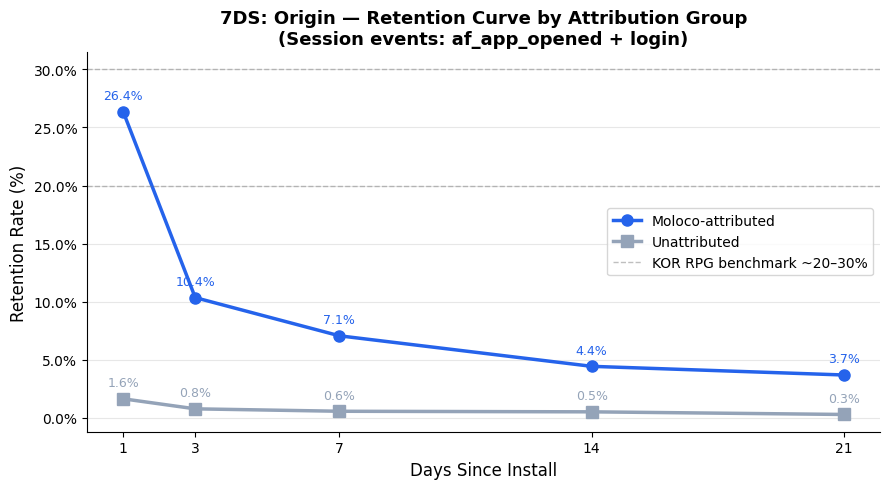

Saved: ua_ltv_retention_curve.png

⚠️  Note: pb session events are only forwarded for Moloco-attributed + some organic users.
   Unattributed series reflects organic users who triggered af_app_opened/login in pb only.


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

for df_s, label, color, marker in [
    (df_attr,   'Moloco-attributed', '#2563EB', 'o'),
    (df_unattr, 'Unattributed',      '#94A3B8', 's'),
]:
    ax.plot(df_s['retention_day'], df_s['retention_rate'] * 100,
            marker=marker, linewidth=2.5, color=color, markersize=8, label=label)
    for _, row in df_s.iterrows():
        ax.annotate(f"{row['retention_rate']*100:.1f}%",
                    (row['retention_day'], row['retention_rate'] * 100),
                    textcoords='offset points', xytext=(0, 9), ha='center',
                    fontsize=9, color=color)

ax.set_xlabel('Days Since Install', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_title('7DS: Origin — Retention Curve by Attribution Group\n(Session events: af_app_opened + login)', fontsize=13, fontweight='bold')
ax.set_xticks([1, 3, 7, 14, 21])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(y=20, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='KOR RPG benchmark ~20–30%')
ax.axhline(y=30, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_retention_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_retention_curve.png')
print('\n⚠️  Note: pb session events are only forwarded for Moloco-attributed + some organic users.')
print('   Unattributed series reflects organic users who triggered af_app_opened/login in pb only.')


---

## Section 1 — I2P by Retention Milestone

**Objective:** Test H1 — do users who stay longer convert to payers at higher rates?

**Cohort definitions (mutually exclusive, escalating):**

| Segment | Definition |
|---------|------------|
| D0-only | Installed but no non-install event after D0 |
| D1-retained | Active on D1 but NOT active on D7 |
| D7-retained | Active on D7 but NOT active on D14 |
| D14-retained | Active on D14 |

**Revenue observation window:** All revenue events within 14 days of install (D0–D14).

**Restriction:** Only users installed ≥14 days ago (installed ≤ 2026-04-15) for fully-observed D14 window.

In [20]:
SESSION_EVENTS_I2P = "('af_app_opened', 'login')"

q_i2p = f"""
WITH base AS (
  SELECT
    device.ifa                                        AS user_id,
    DATE(timestamp)                                   AS event_date,
    event.name = 'install'                            AS is_install,
    event.name IN {SESSION_EVENTS_I2P}                AS is_session,
    moloco.attributed                                 AS is_attr_event,
    CASE WHEN event.name = 'revenue'
              AND event.revenue_usd.amount > 0
         THEN event.revenue_usd.amount END            AS revenue_amount
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= '2026-05-10'
),
with_install AS (
  SELECT *,
    MIN(CASE WHEN is_install THEN event_date END)
      OVER (PARTITION BY user_id)   AS install_date,
    LOGICAL_OR(is_attr_event)
      OVER (PARTITION BY user_id)   AS is_moloco_attributed
  FROM base
),
user_events AS (
  SELECT user_id, install_date, is_moloco_attributed, is_session, revenue_amount,
    DATE_DIFF(event_date, install_date, DAY) AS day_n
  FROM with_install
  WHERE install_date IS NOT NULL
    AND install_date >= '{LAUNCH_DATE}'
    AND install_date <= DATE_SUB(DATE('{TODAY}'), INTERVAL 14 DAY)
    AND event_date >= install_date
    AND DATE_DIFF(event_date, install_date, DAY) BETWEEN 0 AND 14
),
user_milestones AS (
  SELECT user_id, install_date, is_moloco_attributed,
    MAX(CASE WHEN day_n = 1  AND is_session THEN 1 ELSE 0 END) AS active_d1,
    MAX(CASE WHEN day_n BETWEEN 5 AND 7  AND is_session THEN 1 ELSE 0 END) AS active_d7,
    MAX(CASE WHEN day_n BETWEEN 12 AND 14 AND is_session THEN 1 ELSE 0 END) AS active_d14,
    SUM(revenue_amount) AS total_rev_d14
  FROM user_events
  GROUP BY 1, 2, 3
),
user_segments AS (
  SELECT *,
    CASE
      WHEN active_d14 = 1 THEN 'D14-retained'
      WHEN active_d7  = 1 THEN 'D7-retained'
      WHEN active_d1  = 1 THEN 'D1-retained'
      ELSE 'D0-only'
    END AS retention_segment
  FROM user_milestones
)
SELECT
  retention_segment,
  is_moloco_attributed,
  COUNT(*)                                                      AS n_users,
  COUNTIF(total_rev_d14 > 0)                                   AS n_payers,
  SAFE_DIVIDE(COUNTIF(total_rev_d14 > 0), COUNT(*))            AS i2p_rate,
  SAFE_DIVIDE(SUM(total_rev_d14),
    NULLIF(COUNTIF(total_rev_d14 > 0), 0))                     AS arppu_d14,
  SAFE_DIVIDE(SUM(total_rev_d14), COUNT(*))                    AS arpu_d14,
  SUM(total_rev_d14)                                           AS total_rev_d14
FROM user_segments
GROUP BY 1, 2
ORDER BY
  CASE retention_segment
    WHEN 'D0-only'      THEN 1
    WHEN 'D1-retained'  THEN 2
    WHEN 'D7-retained'  THEN 3
    WHEN 'D14-retained' THEN 4
  END,
  is_moloco_attributed
"""

df_i2p_raw = run_query(q_i2p, 'I2P + ARPPU (retention segment × attribution)')

# Overall (both groups combined)
df_i2p = (
    df_i2p_raw.groupby('retention_segment')
    .agg(n_users=('n_users','sum'), n_payers=('n_payers','sum'),
         total_rev=('total_rev_d14','sum'))
    .reset_index()
)
df_i2p['i2p_rate']  = df_i2p['n_payers'] / df_i2p['n_users']
df_i2p['arppu_d14'] = df_i2p['total_rev'] / df_i2p['n_payers'].replace(0, float('nan'))
df_i2p['arpu_d14']  = df_i2p['total_rev'] / df_i2p['n_users']

print("── Overall I2P + ARPPU ──")
display(df_i2p)


✅ I2P + ARPPU (retention segment × attribution): 8 rows
── Overall I2P + ARPPU ──


,retention_segment,n_users,n_payers,total_rev,i2p_rate,arppu_d14,arpu_d14
0,D0-only,91967,3523,75282.116030,0.038307,21.368753,0.818577
1,D1-retained,1480,201,5906.052944,0.135811,29.383348,3.990576
2,D14-retained,1215,412,27990.841343,0.339095,67.938935,23.03773
3,D7-retained,1221,351,10593.944660,0.287469,30.182179,8.676449


In [21]:
# Add 95% binomial confidence intervals for I2P
from scipy.stats import binom

def binom_ci(n_payers, n_users, confidence=0.95):
    if n_users == 0:
        return (np.nan, np.nan)
    alpha = 1 - confidence
    lo = binom.ppf(alpha/2, n_users, n_payers/n_users) / n_users
    hi = binom.ppf(1 - alpha/2, n_users, n_payers/n_users) / n_users
    return (max(0, lo), min(1, hi))

df_i2p[['i2p_ci_lo', 'i2p_ci_hi']] = df_i2p.apply(
    lambda r: pd.Series(binom_ci(r['n_payers'], r['n_users'])),
    axis=1
)

# Flag unreliable ARPPU segments
df_i2p['arppu_reliable'] = df_i2p['n_payers'] >= 30

display_cols = ['retention_segment', 'n_users', 'n_payers', 'i2p_rate', 'i2p_ci_lo', 'i2p_ci_hi',
                'arppu_d14', 'arpu_d14', 'arppu_reliable']
print(df_i2p[display_cols].to_string(index=False))

retention_segment  n_users  n_payers  i2p_rate  i2p_ci_lo  i2p_ci_hi  arppu_d14  arpu_d14  arppu_reliable
          D0-only    91967      3523  0.038307   0.037068   0.039558  21.368753  0.818577            True
      D1-retained     1480       201  0.135811   0.118919   0.153378  29.383348  3.990576            True
     D14-retained     1215       412  0.339095   0.312757   0.365432  67.938935  23.03773            True
      D7-retained     1221       351  0.287469   0.262080   0.312858  30.182179  8.676449            True


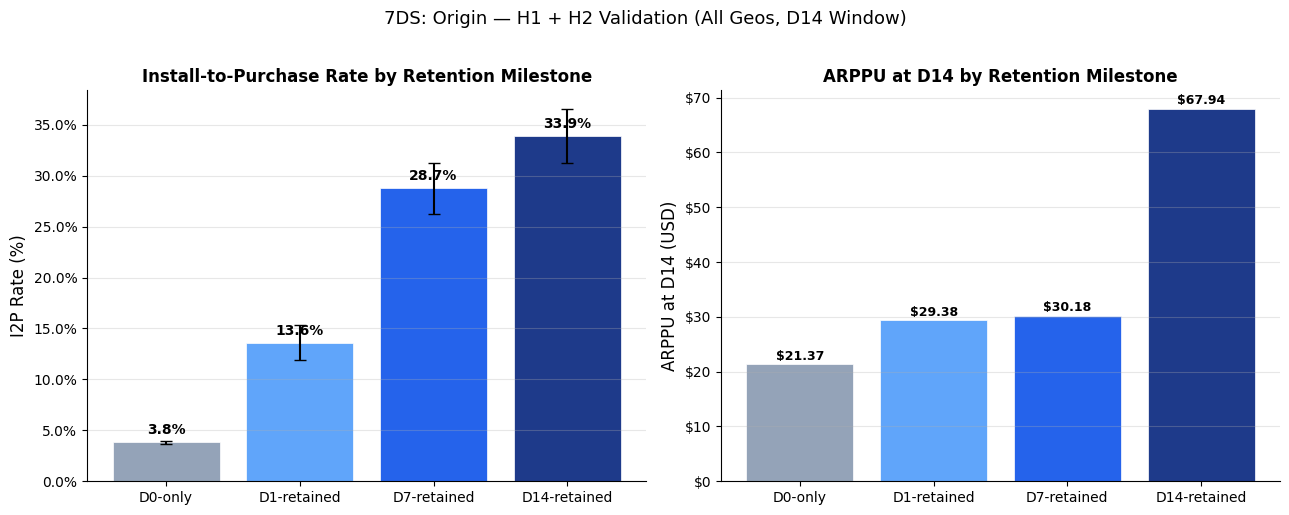

Saved: ua_ltv_i2p_arppu_by_segment.png


In [22]:
SEGMENT_ORDER = ['D0-only', 'D1-retained', 'D7-retained', 'D14-retained']
SEGMENT_COLORS = ['#94A3B8', '#60A5FA', '#2563EB', '#1E3A8A']

df_plot = df_i2p.set_index('retention_segment').loc[SEGMENT_ORDER].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: I2P rate with CI error bars
ax = axes[0]
bars = ax.bar(
    df_plot['retention_segment'],
    df_plot['i2p_rate'] * 100,
    color=SEGMENT_COLORS, edgecolor='white', linewidth=0.5
)
yerr_lo = (df_plot['i2p_rate'] - df_plot['i2p_ci_lo']) * 100
yerr_hi = (df_plot['i2p_ci_hi'] - df_plot['i2p_rate']) * 100
ax.errorbar(
    df_plot['retention_segment'], df_plot['i2p_rate'] * 100,
    yerr=[yerr_lo, yerr_hi], fmt='none', color='black', capsize=4, linewidth=1.5
)
for bar, val in zip(bars, df_plot['i2p_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('I2P Rate (%)', fontsize=12)
ax.set_title('Install-to-Purchase Rate by Retention Milestone', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)

# Right: ARPPU D14
ax2 = axes[1]
bars2 = ax2.bar(
    df_plot['retention_segment'],
    df_plot['arppu_d14'],
    color=SEGMENT_COLORS, edgecolor='white', linewidth=0.5
)
for bar, (val, reliable) in zip(bars2, zip(df_plot['arppu_d14'], df_plot['arppu_reliable'])):
    label = f'${val:.2f}' if reliable else f'${val:.2f}\n(n<30, dir.)'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             label, ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('ARPPU at D14 (USD)', fontsize=12)
ax2.set_title('ARPPU at D14 by Retention Milestone', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.suptitle('7DS: Origin — H1 + H2 Validation (All Geos, D14 Window)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_i2p_arppu_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_i2p_arppu_by_segment.png')

### Attribution Sub-section — I2P & ARPPU by Retention Milestone × Attribution Group

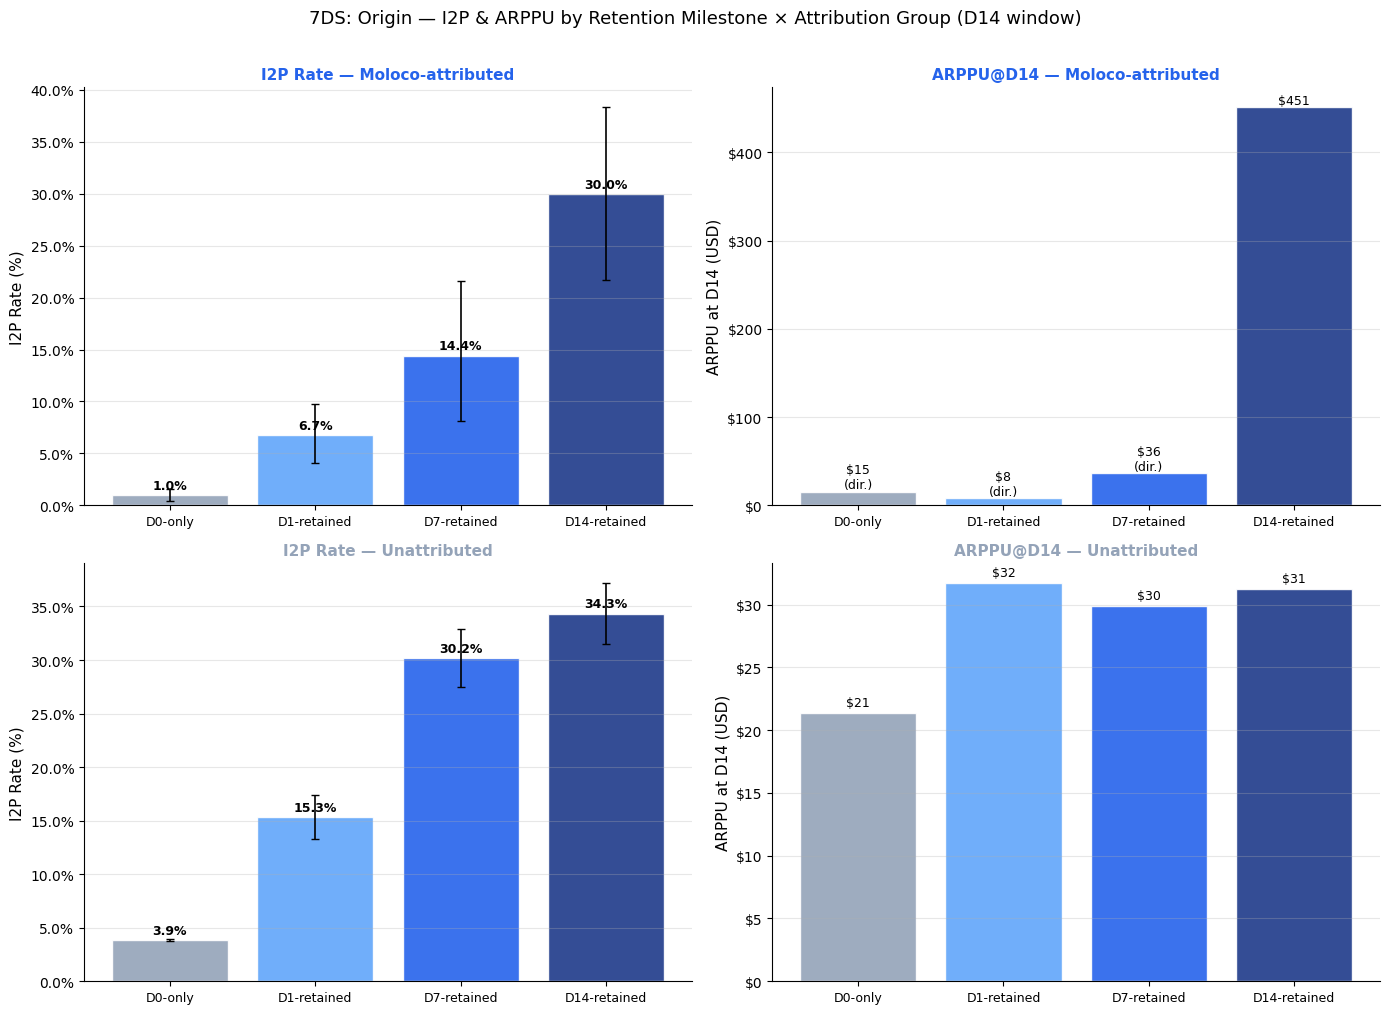

Saved: ua_ltv_i2p_arppu_by_segment.png


In [23]:
# ── Attribution sub-section: I2P + ARPPU split by Moloco-attributed vs Unattributed ──

from scipy.stats import binom

def binom_ci(n_payers, n_users, confidence=0.95):
    if n_users == 0: return (float('nan'), float('nan'))
    alpha = 1 - confidence
    lo = binom.ppf(alpha/2, n_users, max(n_payers/n_users, 1e-9)) / n_users
    hi = binom.ppf(1 - alpha/2, n_users, max(n_payers/n_users, 1e-9)) / n_users
    return (max(0, lo), min(1, hi))

SEGMENT_ORDER = ['D0-only', 'D1-retained', 'D7-retained', 'D14-retained']
SEGMENT_COLORS = ['#94A3B8', '#60A5FA', '#2563EB', '#1E3A8A']
ATTR_LABELS = {True: 'Moloco-attributed', False: 'Unattributed'}
ATTR_COLORS = {True: '#2563EB', False: '#94A3B8'}

# Add CI + reliable flags
df_i2p_raw['i2p_ci_lo'], df_i2p_raw['i2p_ci_hi'] = zip(*df_i2p_raw.apply(
    lambda r: binom_ci(r['n_payers'], r['n_users']), axis=1))
df_i2p_raw['arppu_reliable'] = df_i2p_raw['n_payers'] >= 30

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, metric in enumerate(['i2p_rate', 'arppu_d14']):
    for row_idx, attr_flag in enumerate([True, False]):
        ax = axes[row_idx][col_idx]
        sub = df_i2p_raw[df_i2p_raw['is_moloco_attributed'] == attr_flag]
        sub = sub.set_index('retention_segment').reindex(SEGMENT_ORDER).reset_index()

        vals = sub[metric].fillna(0)
        bars = ax.bar(sub['retention_segment'], vals * (100 if metric == 'i2p_rate' else 1),
                      color=SEGMENT_COLORS, alpha=0.9, edgecolor='white')

        if metric == 'i2p_rate':
            yerr_lo = (sub['i2p_rate'] - sub['i2p_ci_lo']) * 100
            yerr_hi = (sub['i2p_ci_hi'] - sub['i2p_rate']) * 100
            ax.errorbar(sub['retention_segment'], sub['i2p_rate'] * 100,
                        yerr=[yerr_lo.fillna(0), yerr_hi.fillna(0)],
                        fmt='none', color='black', capsize=3, linewidth=1.2)
            for bar, val in zip(bars, sub['i2p_rate']):
                if not np.isnan(val):
                    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
            ax.yaxis.set_major_formatter(mtick.PercentFormatter())
            ax.set_ylabel('I2P Rate (%)', fontsize=11)
            ax.set_title(f'I2P Rate — {ATTR_LABELS[attr_flag]}', fontsize=11, fontweight='bold',
                         color=ATTR_COLORS[attr_flag])
        else:
            for bar, (val, rel) in zip(bars, zip(sub['arppu_d14'], sub['arppu_reliable'])):
                if not np.isnan(val):
                    lbl = f'${val:.0f}' if rel else f'${val:.0f}\n(dir.)'
                    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                            lbl, ha='center', va='bottom', fontsize=9)
            ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
            ax.set_ylabel('ARPPU at D14 (USD)', fontsize=11)
            ax.set_title(f'ARPPU@D14 — {ATTR_LABELS[attr_flag]}', fontsize=11, fontweight='bold',
                         color=ATTR_COLORS[attr_flag])

        ax.tick_params(axis='x', labelsize=9)
        ax.grid(axis='y', alpha=0.3)
        sns.despine(ax=ax)

plt.suptitle('7DS: Origin — I2P & ARPPU by Retention Milestone × Attribution Group (D14 window)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_i2p_arppu_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_i2p_arppu_by_segment.png')


---

## Section 2 — ARPPU Distribution by Retention Milestone

**Objective:** Test H2 deeper — are ARPPU differences driven by genuine engagement lift or a handful of whales in small segments?

**Outputs:** Median, P75, P90 per-user revenue by segment; whale concentration flag.

In [24]:
q_arppu_dist = f"""
WITH base AS (
  SELECT
    device.ifa                                        AS user_id,
    DATE(timestamp)                                   AS event_date,
    event.name = 'install'                            AS is_install,
    event.name IN ('af_app_opened', 'login')          AS is_session,
    moloco.attributed                                 AS is_attr_event,
    CASE WHEN event.name = 'revenue'
              AND event.revenue_usd.amount > 0
         THEN event.revenue_usd.amount END            AS revenue_amount
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= '2026-05-10'
),
with_install AS (
  SELECT *,
    MIN(CASE WHEN is_install THEN event_date END)
      OVER (PARTITION BY user_id)   AS install_date,
    LOGICAL_OR(is_attr_event)
      OVER (PARTITION BY user_id)   AS is_moloco_attributed
  FROM base
),
user_events AS (
  SELECT user_id, install_date, is_moloco_attributed, is_session, revenue_amount,
    DATE_DIFF(event_date, install_date, DAY) AS day_n
  FROM with_install
  WHERE install_date IS NOT NULL
    AND install_date >= '{LAUNCH_DATE}'
    AND install_date <= DATE_SUB(DATE('{TODAY}'), INTERVAL 14 DAY)
    AND event_date >= install_date
    AND DATE_DIFF(event_date, install_date, DAY) BETWEEN 0 AND 14
),
user_milestones AS (
  SELECT user_id, install_date, is_moloco_attributed,
    MAX(CASE WHEN day_n = 1 AND is_session THEN 1 ELSE 0 END) AS active_d1,
    MAX(CASE WHEN day_n BETWEEN 5 AND 7 AND is_session THEN 1 ELSE 0 END) AS active_d7,
    MAX(CASE WHEN day_n BETWEEN 12 AND 14 AND is_session THEN 1 ELSE 0 END) AS active_d14,
    SUM(revenue_amount) AS total_rev_d14
  FROM user_events GROUP BY 1, 2, 3
)
SELECT
  user_id,
  is_moloco_attributed,
  CASE
    WHEN active_d14 = 1 THEN 'D14-retained'
    WHEN active_d7  = 1 THEN 'D7-retained'
    WHEN active_d1  = 1 THEN 'D1-retained'
    ELSE 'D0-only'
  END AS retention_segment,
  total_rev_d14
FROM user_milestones
WHERE total_rev_d14 > 0   -- payers only
"""

df_arppu_dist = run_query(q_arppu_dist, 'ARPPU distribution (payers only)')
print(df_arppu_dist.groupby(['retention_segment','is_moloco_attributed'])['total_rev_d14']
      .agg(['count','median','mean']).round(2))


✅ ARPPU distribution (payers only): 4489 rows
                                        count  median    mean
retention_segment is_moloco_attributed                       
D0-only           False                  3514    5.37   21.38
                  True                     11    4.90   15.49
D1-retained       False                   181    4.92   31.69
                  True                     20    3.79    8.48
D14-retained      False                   376    4.93   31.25
                  True                     36   15.29  451.15
D7-retained       False                   335    5.40   29.89
                  True                     16   11.22   36.33


In [25]:
# Distribution stats per segment
dist_stats = (
    df_arppu_dist
    .groupby('retention_segment')['total_rev_d14']
    .agg(['count', 'median',
          lambda x: x.quantile(0.75),
          lambda x: x.quantile(0.90),
          'mean', 'sum'])
    .rename(columns={'<lambda_0>': 'P75', '<lambda_1>': 'P90'})
    .reset_index()
)
dist_stats = dist_stats.loc[
    dist_stats['retention_segment'].map(dict(zip(SEGMENT_ORDER, range(4)))).argsort()
]
print(dist_stats.to_string(index=False))

# Whale check: % of revenue from top 10% of payers
print('\n--- Whale concentration (% revenue from top 10% payers) ---')
for seg in SEGMENT_ORDER:
    sub = df_arppu_dist[df_arppu_dist['retention_segment'] == seg]['total_rev_d14']
    if len(sub) < 10:
        print(f'{seg}: n={len(sub)} — too few to compute')
        continue
    p90_thresh = sub.quantile(0.9)
    whale_rev = sub[sub >= p90_thresh].sum()
    whale_pct = whale_rev / sub.sum() * 100
    print(f'{seg}: n={len(sub)}, top 10% payers = {whale_pct:.1f}% of revenue')

retention_segment  count   median       P75       P90      mean          sum
          D0-only   3525 5.369171 16.802128 53.801234 21.362956 75304.420930
      D1-retained    201 4.918657 12.210776 52.799309 29.383348  5906.052944
      D7-retained    351 5.399541 19.567071 72.486001 30.182179 10593.944660
     D14-retained    412 4.931333 21.850990 83.254098 67.938935 27990.841343

--- Whale concentration (% revenue from top 10% payers) ---
D0-only: n=3525, top 10% payers = 63.4% of revenue
D1-retained: n=201, top 10% payers = 76.4% of revenue
D7-retained: n=351, top 10% payers = 68.8% of revenue
D14-retained: n=412, top 10% payers = 85.9% of revenue



── Moloco-attributed — top 10% payer revenue share ──
  D0-only: n=11, top 10% = 76.4% of revenue
  D1-retained: n=20, top 10% = 49.4% of revenue
  D7-retained: n=16, top 10% = 52.7% of revenue
  D14-retained: n=36, top 10% = 95.2% of revenue

── Unattributed — top 10% payer revenue share ──
  D0-only: n=3514, top 10% = 63.4% of revenue
  D1-retained: n=181, top 10% = 76.8% of revenue
  D7-retained: n=335, top 10% = 69.4% of revenue
  D14-retained: n=376, top 10% = 72.0% of revenue


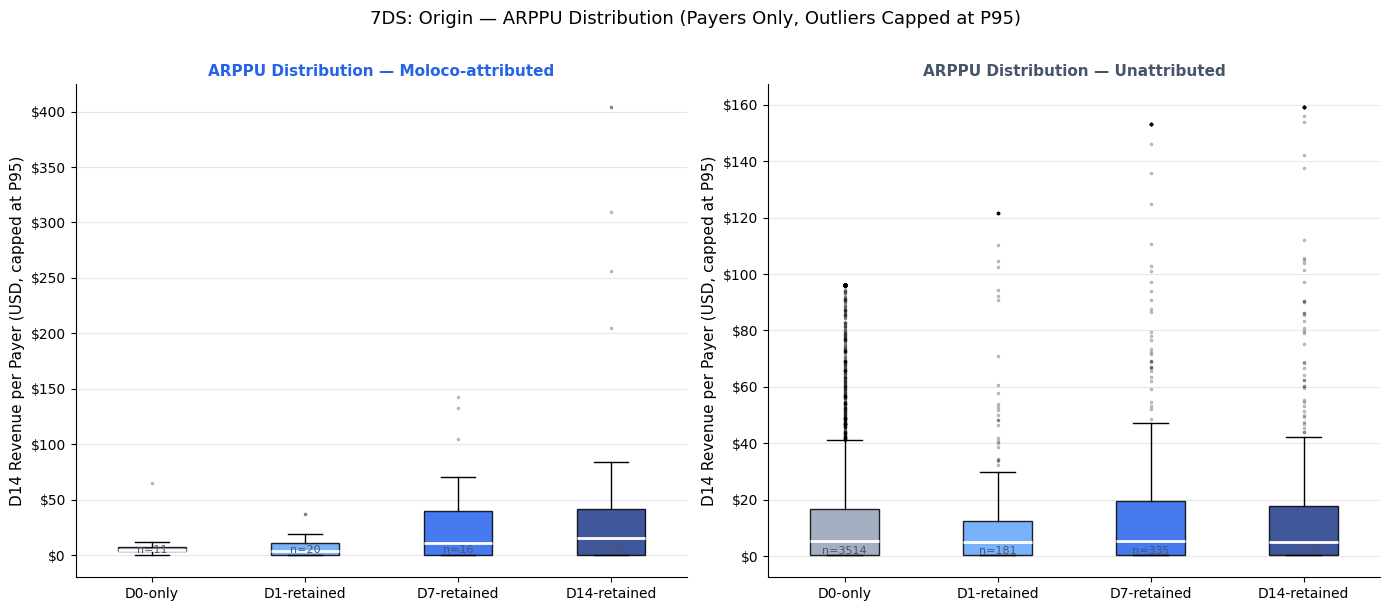

Saved: ua_ltv_arppu_distribution.png
Note: Whiskers show P5–P95 range; dots beyond whiskers are outliers visible but capped for axis scale.


In [26]:
SEGMENT_ORDER = ['D0-only', 'D1-retained', 'D7-retained', 'D14-retained']
SEGMENT_COLORS = ['#94A3B8', '#60A5FA', '#2563EB', '#1E3A8A']

# ── Outlier handling: cap at P95 per segment for visual clarity ───────────────
def cap_outliers(series, upper_pct=95):
    cap = np.percentile(series.dropna(), upper_pct)
    return series.clip(upper=cap)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (attr_flag, attr_label) in enumerate([(True, 'Moloco-attributed'), (False, 'Unattributed')]):
    ax = axes[ax_idx]
    sub = df_arppu_dist[df_arppu_dist['is_moloco_attributed'] == attr_flag]

    data_by_seg = [
        cap_outliers(sub[sub['retention_segment'] == seg]['total_rev_d14']).values
        for seg in SEGMENT_ORDER
    ]
    counts = [len(sub[sub['retention_segment'] == seg]) for seg in SEGMENT_ORDER]

    bp = ax.boxplot(data_by_seg, labels=SEGMENT_ORDER, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.3),
                    showfliers=True)

    for patch, color in zip(bp['boxes'], SEGMENT_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.85)

    # Annotate n per segment
    for i, (seg, n) in enumerate(zip(SEGMENT_ORDER, counts)):
        ax.text(i+1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
                f'n={n}', ha='center', va='bottom', fontsize=8, color='#475569')

    ax.set_ylabel('D14 Revenue per Payer (USD, capped at P95)', fontsize=11)
    ax.set_title(f'ARPPU Distribution — {attr_label}', fontsize=11, fontweight='bold',
                 color='#2563EB' if attr_flag else '#475569')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

    # Whale check
    print(f"\n── {attr_label} — top 10% payer revenue share ──")
    for seg in SEGMENT_ORDER:
        s = sub[sub['retention_segment'] == seg]['total_rev_d14']
        if len(s) >= 10:
            p90 = s.quantile(0.9); whale_pct = s[s >= p90].sum() / s.sum() * 100
            print(f"  {seg}: n={len(s)}, top 10% = {whale_pct:.1f}% of revenue")
        else:
            print(f"  {seg}: n={len(s)} — too few to compute")

plt.suptitle('7DS: Origin — ARPPU Distribution (Payers Only, Outliers Capped at P95)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_arppu_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_arppu_distribution.png')
print('Note: Whiskers show P5–P95 range; dots beyond whiskers are outliers visible but capped for axis scale.')


---

## Section 3 — Monetization Curve (ARPU Progression)

**Objective:** Test H3 — how does cumulative ARPU accumulate over time for the full install cohort? What % of D14 revenue is earned by D1 / D3 / D7?

**Interpretation:** A front-loaded title (>50% revenue by D3) has different UA economics than a back-loaded one — front-loaded titles favor CPI bidding; back-loaded titles favor ROAS with longer attribution windows.

**Restriction:** Users installed ≥14 days ago for full D14 observation.

In [27]:
q_monetization_curve = f"""
WITH installs AS (
  SELECT device.ifa AS user_id, DATE(MIN(timestamp)) AS install_date
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND event.name = 'install'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= DATE_SUB(DATE('{TODAY}'), INTERVAL 14 DAY)
  GROUP BY device.ifa
),

revenue_by_day AS (
  SELECT
    i.user_id,
    DATE_DIFF(DATE(pb.timestamp), i.install_date, DAY) AS day_since_install,
    SUM(pb.event.revenue_usd.amount)                   AS daily_rev
  FROM `{PB_TABLE}` pb
  INNER JOIN installs i ON pb.device.ifa = i.user_id
  WHERE pb.app.bundle = '{BUNDLE_ID}'
    AND pb.event.name = 'revenue'
    AND pb.event.revenue_usd.amount > 0
    AND pb.device.ifa IS NOT NULL
    AND DATE(pb.timestamp) BETWEEN i.install_date AND DATE_ADD(i.install_date, INTERVAL 14 DAY)
    AND DATE(pb.timestamp) >= '2026-04-06'
    AND DATE(pb.timestamp) <= '2026-05-10'
  GROUP BY 1, 2
),

cohort_size AS (
  SELECT COUNT(DISTINCT user_id) AS n_users FROM installs
)

SELECT
  day_since_install,
  SUM(daily_rev)                            AS daily_total_rev,
  cs.n_users,
  SUM(SUM(daily_rev)) OVER (
    ORDER BY day_since_install
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
  )                                          AS cumulative_rev,
  SAFE_DIVIDE(
    SUM(SUM(daily_rev)) OVER (
      ORDER BY day_since_install
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ),
    cs.n_users
  )                                          AS cumulative_arpu
FROM revenue_by_day
CROSS JOIN cohort_size cs
WHERE day_since_install BETWEEN 0 AND 14
GROUP BY day_since_install, cs.n_users
ORDER BY day_since_install
"""

df_monetization = run_query(q_monetization_curve, 'Monetization curve D0–D14')
df_monetization

✅ Monetization curve D0–D14: 15 rows


,day_since_install,daily_total_rev,n_users,cumulative_rev,cumulative_arpu
0,0,14753.990006,95883,14753.990006,0.153875
1,1,15187.780138,95883,29941.770144,0.312274
2,2,12271.237753,95883,42213.007897,0.440255
3,3,8554.271166,95883,50767.279063,0.529471
4,4,6848.186597,95883,57615.465660,0.600893
5,5,6169.661289,95883,63785.126950,0.665239
6,6,4579.208757,95883,68364.335707,0.712997
7,7,4681.608433,95883,73045.944140,0.761824
8,8,6302.961752,95883,79348.905891,0.827560
9,9,5166.320216,95883,84515.226107,0.881441


D14 cumulative ARPU: $1.2494
  D1: $0.3123 = 25.0% of D14 ARPU
  D3: $0.5295 = 42.4% of D14 ARPU
  D7: $0.7618 = 61.0% of D14 ARPU


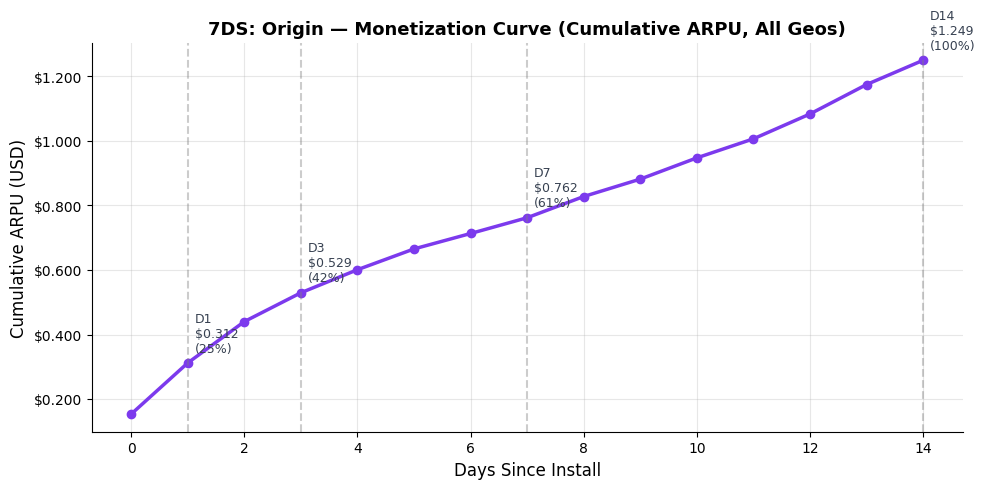

Saved: ua_ltv_monetization_curve.png


In [28]:
# % of D14 ARPU captured at D1, D3, D7
arpu_d14 = df_monetization[df_monetization['day_since_install'] == 14]['cumulative_arpu'].values
arpu_d14 = arpu_d14[0] if len(arpu_d14) > 0 else np.nan

print(f"D14 cumulative ARPU: ${arpu_d14:.4f}")
for milestone in [1, 3, 7]:
    row = df_monetization[df_monetization['day_since_install'] == milestone]
    if not row.empty:
        arpu_m = row['cumulative_arpu'].values[0]
        pct = arpu_m / arpu_d14 * 100 if arpu_d14 > 0 else np.nan
        print(f"  D{milestone}: ${arpu_m:.4f} = {pct:.1f}% of D14 ARPU")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_monetization['day_since_install'], df_monetization['cumulative_arpu'],
        marker='o', linewidth=2.5, color='#7C3AED', markersize=6)

for milestone in [1, 3, 7, 14]:
    row = df_monetization[df_monetization['day_since_install'] == milestone]
    if not row.empty:
        y = row['cumulative_arpu'].values[0]
        pct = y / arpu_d14 * 100 if arpu_d14 > 0 else np.nan
        ax.axvline(x=milestone, color='gray', linestyle='--', alpha=0.4)
        ax.annotate(f'D{milestone}\n${y:.3f}\n({pct:.0f}%)',
                    (milestone, y), textcoords='offset points',
                    xytext=(5, 8), fontsize=9, color='#374151')

ax.set_xlabel('Days Since Install', fontsize=12)
ax.set_ylabel('Cumulative ARPU (USD)', fontsize=12)
ax.set_title('7DS: Origin — Monetization Curve (Cumulative ARPU, All Geos)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.3f'))
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_monetization_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_monetization_curve.png')

---

## Section 4 — Time-to-First-Purchase Distribution

**Objective:** When do users decide to pay? If 80% of payers convert within D3, then D3 is the critical monetization window and UA creative/targeting should prioritize early engagement.

**Output:** Histogram of TTP (D0–D14); CDF showing 50th and 80th percentile conversion day.

In [29]:
q_ttp = f"""
WITH installs AS (
  SELECT device.ifa AS user_id, DATE(MIN(timestamp)) AS install_date
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND event.name = 'install'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= DATE_SUB(DATE('{TODAY}'), INTERVAL 14 DAY)
  GROUP BY device.ifa
),

first_purchase AS (
  SELECT
    pb.device.ifa                                          AS user_id,
    DATE_DIFF(DATE(MIN(pb.timestamp)), i.install_date, DAY) AS days_to_first_purchase
  FROM `{PB_TABLE}` pb
  INNER JOIN installs i ON pb.device.ifa = i.user_id
  WHERE pb.app.bundle = '{BUNDLE_ID}'
    AND pb.event.name = 'revenue'
    AND pb.event.revenue_usd.amount > 0
    AND pb.device.ifa IS NOT NULL
    AND DATE(pb.timestamp) BETWEEN i.install_date AND DATE_ADD(i.install_date, INTERVAL 14 DAY)
    AND DATE(pb.timestamp) >= '2026-04-06'
    AND DATE(pb.timestamp) <= '2026-05-10'
  GROUP BY pb.device.ifa, i.install_date
)

SELECT
  days_to_first_purchase,
  COUNT(*) AS n_payers
FROM first_purchase
WHERE days_to_first_purchase BETWEEN 0 AND 14
GROUP BY 1
ORDER BY 1
"""

df_ttp = run_query(q_ttp, 'Time to first purchase distribution')
df_ttp['cumulative_payers'] = df_ttp['n_payers'].cumsum()
df_ttp['cumulative_pct'] = df_ttp['cumulative_payers'] / df_ttp['n_payers'].sum() * 100
df_ttp

✅ Time to first purchase distribution: 15 rows


,days_to_first_purchase,n_payers,cumulative_payers,cumulative_pct
0,0,1124,1124,25.038984
1,1,856,1980,44.107819
2,2,477,2457,54.733794
3,3,368,2825,62.931611
4,4,283,3108,69.23591
5,5,216,3324,74.047672
6,6,159,3483,77.589664
7,7,164,3647,81.243039
8,8,138,3785,84.31722
9,9,140,3925,87.435955


50% of payers convert by Day 2
80% of payers convert by Day 7


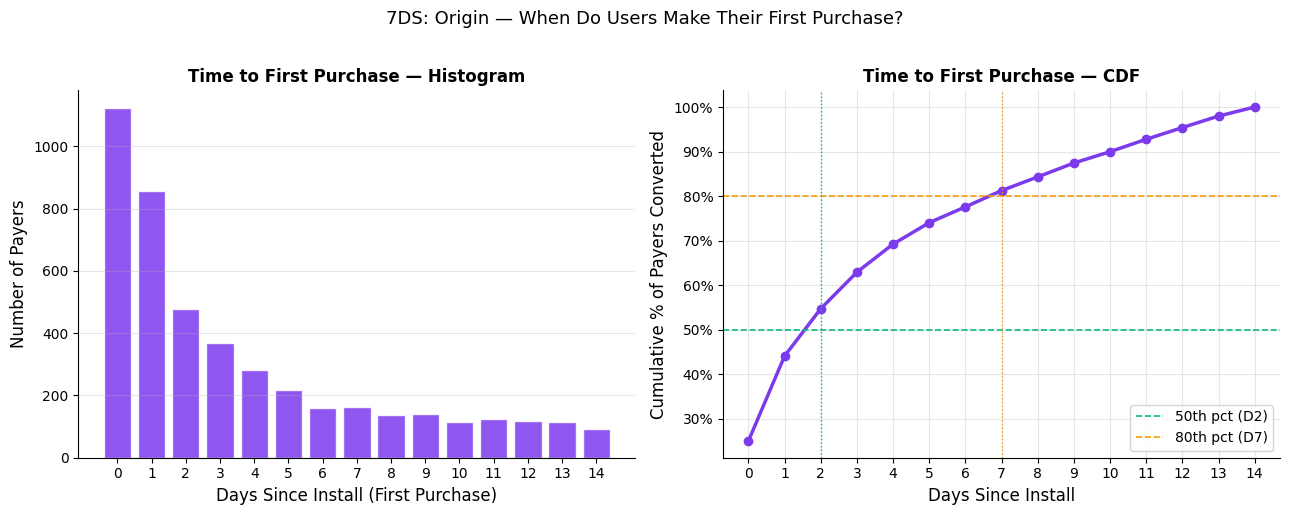

Saved: ua_ltv_ttp_distribution.png


In [30]:
# Find D50 and D80 (day by which 50% / 80% of payers have converted)
d50 = df_ttp[df_ttp['cumulative_pct'] >= 50]['days_to_first_purchase'].iloc[0]
d80 = df_ttp[df_ttp['cumulative_pct'] >= 80]['days_to_first_purchase'].iloc[0]
print(f'50% of payers convert by Day {d50}')
print(f'80% of payers convert by Day {d80}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histogram
ax = axes[0]
ax.bar(df_ttp['days_to_first_purchase'], df_ttp['n_payers'],
       color='#7C3AED', alpha=0.85, edgecolor='white')
ax.set_xlabel('Days Since Install (First Purchase)', fontsize=12)
ax.set_ylabel('Number of Payers', fontsize=12)
ax.set_title('Time to First Purchase — Histogram', fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 15))
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)

# Right: CDF
ax2 = axes[1]
ax2.plot(df_ttp['days_to_first_purchase'], df_ttp['cumulative_pct'],
         marker='o', linewidth=2.5, color='#7C3AED', markersize=6)
ax2.axhline(y=50, color='#10B981', linestyle='--', linewidth=1.2, label=f'50th pct (D{d50})')
ax2.axhline(y=80, color='#F59E0B', linestyle='--', linewidth=1.2, label=f'80th pct (D{d80})')
ax2.axvline(x=d50, color='#10B981', linestyle=':', linewidth=1)
ax2.axvline(x=d80, color='#F59E0B', linestyle=':', linewidth=1)
ax2.set_xlabel('Days Since Install', fontsize=12)
ax2.set_ylabel('Cumulative % of Payers Converted', fontsize=12)
ax2.set_title('Time to First Purchase — CDF', fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, 15))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
sns.despine(ax=ax2)

plt.suptitle('7DS: Origin — When Do Users Make Their First Purchase?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_ttp_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_ttp_distribution.png')

---

## Section 5 — UA Implication: LTV-Adjusted CPA Target

**Objective:** Translate retention/LTV findings into a UA CPA target framework. Compare Moloco-attributed vs. unattributed users on retention quality and I2P.

**Logic:**
```
LTV-adjusted max CPI = Expected ARPU at D14 × (1 − target margin)
```

**Attribution split:** Use `LOGICAL_OR(moloco.attributed)` across all events for each install user.

**Caveat:** Comparing Moloco vs. unattributed users has selection bias — Moloco targeted specific segments. Quality difference may reflect targeting precision, not pure incremental lift.

In [31]:
q_attribution_split = f"""
WITH installs AS (
  SELECT
    device.ifa                       AS user_id,
    DATE(MIN(timestamp))             AS install_date,
    LOGICAL_OR(moloco.attributed)    AS is_moloco_attributed
  FROM `{PB_TABLE}`
  WHERE app.bundle = '{BUNDLE_ID}'
    AND event.name = 'install'
    AND device.ifa IS NOT NULL
    AND DATE(timestamp) >= '{LAUNCH_DATE}'
    AND DATE(timestamp) <= DATE_SUB(DATE('{TODAY}'), INTERVAL 14 DAY)
  GROUP BY device.ifa
),
activity AS (
  SELECT pb.device.ifa AS user_id,
    DATE_DIFF(DATE(pb.timestamp), i.install_date, DAY) AS days_since_install
  FROM `{PB_TABLE}` pb
  INNER JOIN installs i ON pb.device.ifa = i.user_id
  WHERE pb.app.bundle = '{BUNDLE_ID}'
    AND pb.event.name != 'install'
    AND pb.device.ifa IS NOT NULL
    AND DATE(pb.timestamp) BETWEEN i.install_date AND DATE_ADD(i.install_date, INTERVAL 14 DAY)
    AND DATE(pb.timestamp) >= '2026-04-06'
    AND DATE(pb.timestamp) <= '2026-05-10'
  GROUP BY 1, 2
),
revenue AS (
  SELECT pb.device.ifa AS user_id, SUM(pb.event.revenue_usd.amount) AS total_rev_d14
  FROM `{PB_TABLE}` pb
  INNER JOIN installs i ON pb.device.ifa = i.user_id
  WHERE pb.app.bundle = '{BUNDLE_ID}'
    AND pb.event.name = 'revenue'
    AND pb.event.revenue_usd.amount > 0
    AND pb.device.ifa IS NOT NULL
    AND DATE(pb.timestamp) BETWEEN i.install_date AND DATE_ADD(i.install_date, INTERVAL 14 DAY)
    AND DATE(pb.timestamp) >= '2026-04-06'
    AND DATE(pb.timestamp) <= '2026-05-10'
  GROUP BY 1
),
user_milestones AS (
  SELECT i.user_id, i.is_moloco_attributed,
    MAX(CASE WHEN a.days_since_install = 1 THEN 1 ELSE 0 END)  AS active_d1,
    MAX(CASE WHEN a.days_since_install BETWEEN 5 AND 7 THEN 1 ELSE 0 END) AS active_d7,
    MAX(CASE WHEN a.days_since_install BETWEEN 12 AND 14 THEN 1 ELSE 0 END) AS active_d14
  FROM installs i LEFT JOIN activity a ON i.user_id = a.user_id
  GROUP BY 1, 2
)

SELECT
  CASE WHEN is_moloco_attributed THEN 'Moloco-attributed' ELSE 'Unattributed' END AS attribution_group,
  COUNT(*)                                              AS n_users,
  COUNT(r.user_id)                                      AS n_payers,
  SAFE_DIVIDE(COUNT(r.user_id), COUNT(*))               AS i2p_rate,
  SAFE_DIVIDE(SUM(active_d1), COUNT(*))                 AS d1_retention,
  SAFE_DIVIDE(SUM(active_d7), COUNT(*))                 AS d7_retention,
  SAFE_DIVIDE(SUM(active_d14), COUNT(*))                AS d14_retention,
  SAFE_DIVIDE(SUM(r.total_rev_d14), COUNT(r.user_id))   AS arppu_d14,
  SAFE_DIVIDE(SUM(r.total_rev_d14), COUNT(*))           AS arpu_d14,
  SUM(r.total_rev_d14)                                  AS total_rev
FROM user_milestones um
LEFT JOIN revenue r ON um.user_id = r.user_id
GROUP BY 1
ORDER BY 1
"""

df_attr_split = run_query(q_attribution_split, 'Attribution split: Moloco vs Unattributed')
df_attr_split

KeyboardInterrupt: 

In [ ]:
# LTV-adjusted CPI target framework
# Formula: max_cpi = arpu_d14 × (1 - margin)
TARGET_MARGINS = [0.20, 0.30, 0.40]  # 20%, 30%, 40% margin scenarios

print('=' * 65)
print('LTV-Adjusted Max CPI — D14 ARPU × (1 − margin)')
print('=' * 65)

for _, row in df_attr_split.iterrows():
    grp = row['attribution_group']
    arpu = row['arpu_d14']
    i2p  = row['i2p_rate']
    d7r  = row['d7_retention']
    arppu = row['arppu_d14']
    print(f"\n{grp} (n={row['n_users']:,})")
    print(f"  D7 retention: {d7r*100:.1f}%  |  I2P: {i2p*100:.2f}%  |  ARPU@D14: ${arpu:.4f}  |  ARPPU@D14: ${arppu:.2f}")
    for m in TARGET_MARGINS:
        max_cpi = arpu * (1 - m)
        print(f"  Max CPI at {int(m*100)}% margin: ${max_cpi:.4f}")

print('\n⚠️  CAVEAT: Moloco vs. Unattributed comparison has selection bias.')
print('   Moloco targeted specific audiences — quality gap may reflect targeting, not pure incrementality.')

In [ ]:
# Visualization: attribution group comparison
metrics = ['d1_retention', 'd7_retention', 'd14_retention', 'i2p_rate']
labels  = ['D1 Retention', 'D7 Retention', 'D14 Retention', 'I2P Rate']

moloco_row = df_attr_split[df_attr_split['attribution_group'] == 'Moloco-attributed'].iloc[0]
unattrb_row = df_attr_split[df_attr_split['attribution_group'] == 'Unattributed'].iloc[0]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [moloco_row[m] * 100 for m in metrics],
               width, label=f"Moloco-attributed (n={moloco_row['n_users']:,})",
               color='#2563EB', alpha=0.9)
bars2 = ax.bar(x + width/2, [unattrb_row[m] * 100 for m in metrics],
               width, label=f"Unattributed (n={unattrb_row['n_users']:,})",
               color='#94A3B8', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1E3A8A')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#475569')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title('7DS: Origin — Retention & I2P by Attribution Group', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'ua_ltv_attribution_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ua_ltv_attribution_comparison.png')

---

## Summary

| Hypothesis | Finding | Verdict |
|------------|---------|--------|
| H1: Retained users → higher I2P | *(fill after run)* | *(TBD)* |
| H2: Retained users → higher ARPPU | *(fill after run)* | *(TBD)* |
| H3: Revenue gap widens D7→D14 | *(fill after run)* | *(TBD)* |

**LTV-Adjusted CPI Recommendation:**

| Segment | D14 ARPU | Max CPI (30% margin) | D7 Retention |
|---------|----------|----------------------|-------------|
| Moloco-attributed | *(TBD)* | *(TBD)* | *(TBD)* |
| Unattributed | *(TBD)* | *(TBD)* | *(TBD)* |

---

## Caveats

1. **22-day title history** — D14 findings are directional; re-run at D30 and D60 for mature validation
2. **Retention ≠ causation** — Retention predicts LTV but does not cause it; user quality drives both
3. **Revenue right-censored** — D14 window restricted to fully-observed cohorts (installed ≥14 days ago)
4. **Attribution selection bias** — Moloco vs. unattributed comparison may reflect targeting segment quality, not incrementality
5. **ARPPU skewness** — Flag any segment with n_payers < 30 as unreliable; mobile RPG revenue is whale-driven